In [1]:
import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt
print("Matplotlib:", plt.matplotlib.__version__)

Matplotlib: 3.11.2


In [2]:
fake = Faker()

print("Faker:", fake.name())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Faker: Johnny Thompson
NumPy: 2.4.6
Pandas: 3.0.5


In [3]:
# Number of transactions
NUM_TRANSACTIONS = 10_000

# Number of users
NUM_USERS = 1_000

# Random seed for reproducible results
np.random.seed(42)
random.seed(42)

fake = Faker()
Faker.seed(42)

print("Transactions:", NUM_TRANSACTIONS)
print("Users:", NUM_USERS)

Transactions: 10000
Users: 1000


In [4]:
# Generate user IDs
user_ids = [f"USER_{i:04d}" for i in range(1, NUM_USERS + 1)]

# Generate transaction IDs
transaction_ids = [f"TXN_{i:06d}" for i in range(1, NUM_TRANSACTIONS + 1)]

# Generate timestamps over the last 90 days
timestamps = pd.date_range(
    end=pd.Timestamp.now(),
    periods=NUM_TRANSACTIONS,
    freq="min"
)

# Randomly assign users
senders = np.random.choice(user_ids, NUM_TRANSACTIONS)

# Generate receivers
receivers = [f"USER_{random.randint(1, NUM_USERS):04d}" 
             for _ in range(NUM_TRANSACTIONS)]

# Transaction amounts
amounts = np.round(
    np.random.lognormal(mean=6, sigma=1, size=NUM_TRANSACTIONS),
    2
)

# Merchant categories
merchant_categories = [
    "Grocery",
    "Food",
    "Shopping",
    "Travel",
    "Bills",
    "Entertainment",
    "Healthcare",
    "Education"
]

# Transaction types
transaction_types = [
    "P2P",
    "P2M"
]

# Locations
locations = [
    "Delhi",
    "Mumbai",
    "Bangalore",
    "Hyderabad",
    "Chennai",
    "Kolkata",
    "Pune",
    "Jaipur"
]

# Device types
device_types = [
    "Android",
    "iOS",
    "Web"
]

# UPI channels
upi_channels = [
    "Google Pay",
    "PhonePe",
    "Paytm",
    "BHIM",
    "Other"
]

print("Data components generated successfully.")

Data components generated successfully.


In [5]:
# Create the transaction DataFrame

df = pd.DataFrame({
    "transaction_id": transaction_ids,
    "timestamp": timestamps,
    "sender_id": senders,
    "receiver_id": receivers,
    "amount": amounts,
    "merchant_category": np.random.choice(
        merchant_categories, NUM_TRANSACTIONS
    ),
    "transaction_type": np.random.choice(
        transaction_types, NUM_TRANSACTIONS
    ),
    "location": np.random.choice(
        locations, NUM_TRANSACTIONS
    ),
    "device_type": np.random.choice(
        device_types, NUM_TRANSACTIONS
    ),
    "upi_channel": np.random.choice(
        upi_channels, NUM_TRANSACTIONS
    )
})

# Sort transactions chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

print("Dataset created successfully!")
print("Shape:", df.shape)

Dataset created successfully!
Shape: (10000, 10)


In [6]:
df.head()

,transaction_id,timestamp,sender_id,receiver_id,amount,merchant_category,transaction_type,location,device_type,upi_channel
0,TXN_000001,2026-09-13 13:54:42.793653,USER_0103,USER_0655,210.96,Entertainment,P2P,Mumbai,Android,Paytm
1,TXN_000002,2026-09-13 13:55:42.793653,USER_0436,USER_0115,176.92,Travel,P2P,Chennai,Web,PhonePe
2,TXN_000003,2026-09-13 13:56:42.793653,USER_0861,USER_0026,156.00,Grocery,P2P,Jaipur,iOS,PhonePe
3,TXN_000004,2026-09-13 13:57:42.793653,USER_0271,USER_0760,330.73,Entertainment,P2P,Kolkata,iOS,BHIM
4,TXN_000005,2026-09-13 13:58:42.793653,USER_0107,USER_0282,484.47,Grocery,P2M,Jaipur,Web,PhonePe


In [7]:
# Extract time-based features

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

# Weekend indicator
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Late-night transaction indicator
df["is_late_night"] = (
    (df["hour"] >= 0) & (df["hour"] <= 5)
).astype(int)

print("Time-based features added.")

Time-based features added.


In [8]:
df[[
    "timestamp",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_late_night"
]].head(10)

,timestamp,hour,day_of_week,is_weekend,is_late_night
0,2026-09-13 13:54:42.793653,13,6,1,0
1,2026-09-13 13:55:42.793653,13,6,1,0
2,2026-09-13 13:56:42.793653,13,6,1,0
3,2026-09-13 13:57:42.793653,13,6,1,0
4,2026-09-13 13:58:42.793653,13,6,1,0
5,2026-09-13 13:59:42.793653,13,6,1,0
6,2026-09-13 14:00:42.793653,14,6,1,0
7,2026-09-13 14:01:42.793653,14,6,1,0
8,2026-09-13 14:02:42.793653,14,6,1,0
9,2026-09-13 14:03:42.793653,14,6,1,0


In [9]:
# Calculate user's historical spending statistics

user_stats = df.groupby("sender_id")["amount"].agg(
    user_avg_amount="mean",
    user_median_amount="median",
    user_max_amount="max",
    user_transaction_count="count"
).reset_index()

# Merge these statistics back into the transaction dataset
df = df.merge(user_stats, on="sender_id", how="left")

print("User spending statistics added.")

User spending statistics added.


In [10]:
# Calculate how unusual each transaction amount is
df["amount_deviation"] = (
    df["amount"] / df["user_avg_amount"]
)

df[[
    "sender_id",
    "amount",
    "user_avg_amount",
    "amount_deviation"
]].head(10)

,sender_id,amount,user_avg_amount,amount_deviation
0,USER_0103,210.96,651.420000,0.323846
1,USER_0436,176.92,666.086667,0.265611
2,USER_0861,156.00,232.764444,0.670205
3,USER_0271,330.73,524.282500,0.630824
4,USER_0107,484.47,555.603750,0.871970
5,USER_0072,113.40,1090.812000,0.103959
6,USER_0701,139.26,596.193000,0.233582
7,USER_0021,201.45,646.626364,0.311540
8,USER_0615,155.25,837.871111,0.185291
9,USER_0122,418.53,1223.945455,0.341952


In [11]:
# Calculate number of transactions made by each user
# within the previous 1 hour

df = df.sort_values(["sender_id", "timestamp"]).reset_index(drop=True)

df["transactions_last_1h"] = (
    df.groupby("sender_id")
      .rolling("1h", on="timestamp")["transaction_id"]
      .count()
      .reset_index(level=0, drop=True)
      .values
)

# Remove the current transaction from its own count
df["transactions_last_1h"] = (
    df["transactions_last_1h"] - 1
).clip(lower=0)

print("1-hour transaction frequency calculated.")

1-hour transaction frequency calculated.


In [12]:
df[[
    "sender_id",
    "timestamp",
    "transactions_last_1h"
]].head(15)

,sender_id,timestamp,transactions_last_1h
0,USER_0001,2026-09-14 04:51:42.793653,0.0
1,USER_0001,2026-09-14 07:23:42.793653,0.0
2,USER_0001,2026-09-14 12:31:42.793653,0.0
3,USER_0001,2026-09-14 16:19:42.793653,0.0
4,USER_0001,2026-09-15 11:54:42.793653,0.0
5,USER_0001,2026-09-15 13:13:42.793653,0.0
6,USER_0001,2026-09-16 12:28:42.793653,0.0
7,USER_0001,2026-09-16 17:05:42.793653,0.0
8,USER_0001,2026-09-17 00:08:42.793653,0.0
9,USER_0001,2026-09-17 13:52:42.793653,0.0


In [13]:
# Count how many times each user has sent money
# to the same receiver

df["recipient_repeat_count"] = (
    df.groupby(["sender_id", "receiver_id"])
      .cumcount()
)

print("Recipient repetition feature added.")

Recipient repetition feature added.


In [14]:
df[[
    "sender_id",
    "receiver_id",
    "recipient_repeat_count"
]].head(15)

,sender_id,receiver_id,recipient_repeat_count
0,USER_0001,USER_0451,0
1,USER_0001,USER_0621,0
2,USER_0001,USER_0271,0
3,USER_0001,USER_0956,0
4,USER_0001,USER_0299,0
5,USER_0001,USER_0324,0
6,USER_0001,USER_0578,0
7,USER_0001,USER_0038,0
8,USER_0001,USER_0291,0
9,USER_0001,USER_0911,0


In [15]:
# Make sure transactions are ordered by user and time
df = df.sort_values(["sender_id", "timestamp"]).reset_index(drop=True)

# Previous device used by the same sender
df["previous_device"] = (
    df.groupby("sender_id")["device_type"].shift(1)
)

# Previous location used by the same sender
df["previous_location"] = (
    df.groupby("sender_id")["location"].shift(1)
)

# Detect device change
df["device_changed"] = (
    (df["device_type"] != df["previous_device"]) &
    df["previous_device"].notna()
).astype(int)

# Detect location change
df["location_changed"] = (
    (df["location"] != df["previous_location"]) &
    df["previous_location"].notna()
).astype(int)

print("Device and location change features added.")

Device and location change features added.


In [16]:
df[[
    "sender_id",
    "device_type",
    "previous_device",
    "device_changed",
    "location",
    "previous_location",
    "location_changed"
]].head(15)

,sender_id,device_type,previous_device,device_changed,location,previous_location,location_changed
0,USER_0001,Android,NaN,0,Chennai,NaN,0
1,USER_0001,iOS,Android,1,Bangalore,Chennai,1
2,USER_0001,Web,iOS,1,Jaipur,Bangalore,1
3,USER_0001,Android,Web,1,Jaipur,Jaipur,0
4,USER_0001,Android,Android,0,Jaipur,Jaipur,0
5,USER_0001,Android,Android,0,Kolkata,Jaipur,1
6,USER_0001,Android,Android,0,Pune,Kolkata,1
7,USER_0001,Web,Android,1,Kolkata,Pune,1
8,USER_0001,Android,Web,1,Chennai,Kolkata,1
9,USER_0001,Web,Android,1,Mumbai,Chennai,1


In [17]:
# Create fraud/suspicious transaction flag
df["fraud_label"] = 0

print("Initial fraud labels:")
print(df["fraud_label"].value_counts())

Initial fraud labels:
fraud_label
0    10000
Name: count, dtype: int64


In [18]:
# Flag unusually high-value transactions
high_value_threshold = df["amount"].quantile(0.98)

high_value_indices = df[
    df["amount"] >= high_value_threshold
].index

print("High-value transactions:", len(high_value_indices))

High-value transactions: 200


In [19]:
# Randomly select additional transactions for suspicious behavior
np.random.seed(42)

suspicious_indices = np.random.choice(
    df.index,
    size=500,
    replace=False
)

print("Suspicious transactions selected:", len(suspicious_indices))

Suspicious transactions selected: 500


In [20]:
# Increase transaction amounts for a portion of suspicious transactions

amount_indices = suspicious_indices[:150]

df.loc[amount_indices, "amount"] = (
    df.loc[amount_indices, "amount"] * 
    np.random.uniform(5, 15, len(amount_indices))
).round(2)

df.loc[amount_indices, "fraud_label"] = 1

print("High-value suspicious transactions injected.")

High-value suspicious transactions injected.


In [21]:
# Inject late-night activity

night_indices = suspicious_indices[150:250]

random_hours = np.random.choice(
    [0, 1, 2, 3, 4, 5],
    size=len(night_indices)
)

# Convert the column to a dtype that safely accepts the assignment
df["hour"] = df["hour"].astype("int64")

df.loc[night_indices, "hour"] = random_hours.astype("int64")
df.loc[night_indices, "is_late_night"] = 1
df.loc[night_indices, "fraud_label"] = 1

print("Late-night suspicious transactions injected.")

Late-night suspicious transactions injected.


In [22]:
burst_indices = suspicious_indices[250:350]

df.loc[burst_indices, "transactions_last_1h"] = np.random.randint(
    6, 20, len(burst_indices)
)

df.loc[burst_indices, "fraud_label"] = 1

print("Transaction burst patterns injected.")

Transaction burst patterns injected.


In [23]:
device_indices = suspicious_indices[350:425]

df.loc[device_indices, "device_changed"] = 1
df.loc[device_indices, "fraud_label"] = 1

print("Device-change patterns injected.")

Device-change patterns injected.


In [24]:
location_indices = suspicious_indices[425:500]

df.loc[location_indices, "location_changed"] = 1
df.loc[location_indices, "fraud_label"] = 1

print("Location-change patterns injected.")

Location-change patterns injected.


In [25]:
user_stats = df.groupby("sender_id")["amount"].agg(
    user_avg_amount="mean",
    user_median_amount="median",
    user_max_amount="max",
    user_transaction_count="count"
).reset_index()

df = df.drop(
    columns=[
        "user_avg_amount",
        "user_median_amount",
        "user_max_amount",
        "user_transaction_count"
    ]
)

df = df.merge(
    user_stats,
    on="sender_id",
    how="left"
)

df["amount_deviation"] = (
    df["amount"] / df["user_avg_amount"]
)

print("User statistics updated.")

User statistics updated.


In [26]:
print("Dataset shape:", df.shape)

print("\nFraud distribution:")
print(df["fraud_label"].value_counts())

print("\nFraud percentage:")
print(df["fraud_label"].mean() * 100)

Dataset shape: (10000, 26)

Fraud distribution:
fraud_label
0    9500
1     500
Name: count, dtype: int64

Fraud percentage:
5.0


In [27]:
suspicious_df = df[df["fraud_label"] == 1]

suspicious_df[[
    "transaction_id",
    "sender_id",
    "amount",
    "hour",
    "transactions_last_1h",
    "device_changed",
    "location_changed",
    "amount_deviation",
    "fraud_label"
]].head(20)

,transaction_id,sender_id,amount,hour,transactions_last_1h,device_changed,location_changed,amount_deviation,fraud_label
3,TXN_001586,USER_0001,109.54,16,0.0,1,1,0.208601,1
14,TXN_009152,USER_0001,2385.88,22,0.0,1,0,4.543511,1
29,TXN_005196,USER_0003,135.77,1,0.0,1,1,0.142515,1
31,TXN_006179,USER_0003,1506.83,2,0.0,1,1,1.581686,1
33,TXN_009103,USER_0003,1947.03,21,0.0,0,1,2.043754,1
35,TXN_001817,USER_0004,12023.49,20,0.0,1,1,4.457880,1
39,TXN_000180,USER_0005,7763.08,16,0.0,0,0,7.165758,1
76,TXN_008161,USER_0008,302.08,5,0.0,1,1,0.536671,1
80,TXN_000835,USER_0009,469.44,4,0.0,1,1,1.579162,1
88,TXN_003030,USER_0010,764.04,16,6.0,1,1,1.048017,1


In [28]:
print("NORMAL TRANSACTIONS")
display(
    df[df["fraud_label"] == 0][
        ["amount", "amount_deviation", "transactions_last_1h"]
    ].describe()
)

print("\nSUSPICIOUS TRANSACTIONS")
display(
    df[df["fraud_label"] == 1][
        ["amount", "amount_deviation", "transactions_last_1h"]
    ].describe()
)

NORMAL TRANSACTIONS


,amount,amount_deviation,transactions_last_1h
count,9500.000000,9500.000000,9500.000000
mean,660.165854,0.953071,0.060421
std,841.706805,0.958363,0.246529
min,7.000000,0.005739,0.000000
25%,200.015000,0.309217,0.000000
50%,401.265000,0.642497,0.000000
75%,786.335000,1.261688,0.000000
max,14756.910000,9.538791,3.000000



SUSPICIOUS TRANSACTIONS


,amount,amount_deviation,transactions_last_1h
count,500.000000,500.000000,500.000000
mean,2315.735360,1.891659,2.448000
std,4869.034292,2.065298,5.170761
min,31.520000,0.034752,0.000000
25%,296.097500,0.433606,0.000000
50%,644.165000,1.015728,0.000000
75%,2119.682500,2.601696,0.000000
max,55488.550000,11.970689,19.000000


In [29]:
import os

os.makedirs("../data/raw", exist_ok=True)

df.to_csv(
    "../data/raw/upi_transactions.csv",
    index=False
)

print("Dataset saved successfully!")
print("Location: ../data/raw/upi_transactions.csv")

Dataset saved successfully!
Location: ../data/raw/upi_transactions.csv


In [30]:
print("FINAL DATASET")
print("=" * 40)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nFraud labels:")
print(df["fraud_label"].value_counts())

FINAL DATASET
Rows: 10000
Columns: 26

Columns:
['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount', 'merchant_category', 'transaction_type', 'location', 'device_type', 'upi_channel', 'hour', 'day_of_week', 'is_weekend', 'is_late_night', 'amount_deviation', 'transactions_last_1h', 'recipient_repeat_count', 'previous_device', 'previous_location', 'device_changed', 'location_changed', 'fraud_label', 'user_avg_amount', 'user_median_amount', 'user_max_amount', 'user_transaction_count']

Fraud labels:
fraud_label
0    9500
1     500
Name: count, dtype: int64


In [31]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (10000, 26)

Data Types:
transaction_id                       str
timestamp                 datetime64[us]
sender_id                            str
receiver_id                          str
amount                           float64
merchant_category                    str
transaction_type                     str
location                             str
device_type                          str
upi_channel                          str
hour                               int64
day_of_week                        int32
is_weekend                         int64
is_late_night                      int64
amount_deviation                 float64
transactions_last_1h             float64
recipient_repeat_count             int64
previous_device                      str
previous_location                    str
device_changed                     int64
location_changed                   int64
fraud_label                        int64
user_avg_amount                  float64
user_median_amoun

In [32]:
df.describe()

,timestamp,amount,hour,day_of_week,is_weekend,is_late_night,amount_deviation,transactions_last_1h,recipient_repeat_count,device_changed,location_changed,fraud_label,user_avg_amount,user_median_amount,user_max_amount,user_transaction_count
count,10000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2026-09-17 01:14:12.793652,742.944329,11.40170,2.97600,0.280000,0.259100,1.000000,0.179800,0.005300,0.605400,0.787600,0.050000,742.944329,445.854472,2972.414761,11.097800
min,2026-09-13 13:54:42.793653,7.000000,0.00000,0.00000,0.000000,0.000000,0.005739,0.000000,0.000000,0.000000,0.000000,0.000000,100.385000,85.790000,118.940000,1.000000
25%,2026-09-15 07:34:27.793653,202.987500,5.00000,1.00000,0.000000,0.000000,0.314181,0.000000,0.000000,0.000000,1.000000,0.000000,493.280909,318.270000,1382.130000,9.000000
50%,2026-09-17 01:14:12.793653,410.680000,11.00000,3.00000,0.000000,0.000000,0.654074,0.000000,0.000000,1.000000,1.000000,0.000000,639.625000,406.150000,2040.280000,11.000000
75%,2026-09-18 18:53:57.793653,815.435000,17.00000,5.00000,1.000000,1.000000,1.294645,0.000000,0.000000,1.000000,1.000000,0.000000,858.666364,518.885000,3173.120000,13.000000
max,2026-09-20 12:33:42.793653,55488.550000,23.00000,6.00000,1.000000,1.000000,11.970689,19.000000,1.000000,1.000000,1.000000,1.000000,9677.178333,2393.690000,55488.550000,22.000000
std,NaN,1409.387051,6.97345,1.98993,0.449021,0.438163,1.061720,1.289511,0.072612,0.488789,0.409027,0.217956,475.683154,197.145189,3530.591059,3.293254


In [33]:
fraud_counts = df["fraud_label"].value_counts()

print("Normal transactions:", fraud_counts.get(0, 0))
print("Suspicious transactions:", fraud_counts.get(1, 0))

print(
    "\nSuspicious percentage:",
    round(df["fraud_label"].mean() * 100, 2),
    "%"
)

Normal transactions: 9500
Suspicious transactions: 500

Suspicious percentage: 5.0 %


In [34]:
amount_comparison = df.groupby("fraud_label")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_comparison

,count,mean,median,min,max
fraud_label,,,,,
0,9500,660.165854,401.265,7.00,14756.91
1,500,2315.735360,644.165,31.52,55488.55


In [35]:
# Calculate Q1 and Q3
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 202.98749999999998
Q3: 815.435
IQR: 612.4475
Lower Bound: -715.68375
Upper Bound: 1734.1062499999998


In [36]:
df["iqr_anomaly"] = (
    (df["amount"] < lower_bound) |
    (df["amount"] > upper_bound)
).astype(int)

print("IQR anomalies detected:", df["iqr_anomaly"].sum())

IQR anomalies detected: 825


In [37]:
iqr_comparison = pd.crosstab(
    df["fraud_label"],
    df["iqr_anomaly"],
    rownames=["Actual Synthetic Label"],
    colnames=["IQR Anomaly"]
)

iqr_comparison

IQR Anomaly,0,1
Actual Synthetic Label,,
0,8819,681
1,356,144


In [38]:
normal_iqr_rate = df.loc[
    df["fraud_label"] == 0,
    "iqr_anomaly"
].mean() * 100

fraud_iqr_rate = df.loc[
    df["fraud_label"] == 1,
    "iqr_anomaly"
].mean() * 100

print(
    f"Normal transactions flagged by IQR: {normal_iqr_rate:.2f}%"
)

print(
    f"Suspicious transactions flagged by IQR: {fraud_iqr_rate:.2f}%"
)

Normal transactions flagged by IQR: 7.17%
Suspicious transactions flagged by IQR: 28.80%


In [39]:
df.sort_values(
    "amount",
    ascending=False
)[[
    "transaction_id",
    "sender_id",
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "is_late_night",
    "device_changed",
    "location_changed",
    "fraud_label",
    "iqr_anomaly"
]].head(20)

,transaction_id,sender_id,amount,amount_deviation,transactions_last_1h,is_late_night,device_changed,location_changed,fraud_label,iqr_anomaly
5861,TXN_005836,USER_0592,55488.55,5.733960,0.0,0,0,1,1,1
119,TXN_007987,USER_0012,32067.90,11.466014,1.0,1,1,0,1,1
3145,TXN_004482,USER_0318,31930.57,11.970689,0.0,0,0,1,1,1
8178,TXN_007546,USER_0826,31879.57,7.186081,0.0,0,0,1,1,1
2249,TXN_007664,USER_0225,29876.16,9.225554,0.0,0,1,1,1,1
9417,TXN_008232,USER_0942,28236.80,7.151619,0.0,0,1,0,1,1
3973,TXN_005018,USER_0403,24743.54,6.227771,0.0,1,1,1,1,1
1731,TXN_004397,USER_0174,19929.60,2.946901,0.0,0,1,0,1,1
9753,TXN_002198,USER_0975,18089.48,8.294605,0.0,1,0,1,1,1
2340,TXN_005338,USER_0233,16288.23,6.831215,0.0,0,1,1,1,1


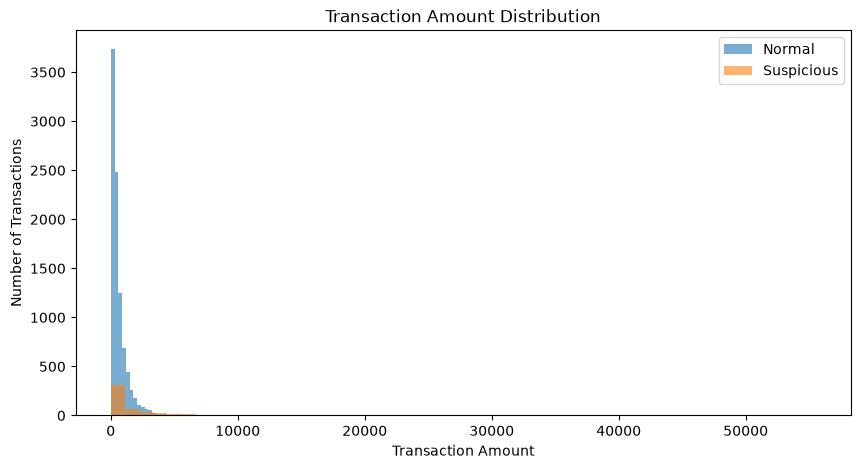

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["fraud_label"] == 0]["amount"],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df[df["fraud_label"] == 1]["amount"],
    bins=50,
    alpha=0.6,
    label="Suspicious"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.legend()
plt.show()

In [41]:
df.to_csv(
    "../data/raw/upi_transactions.csv",
    index=False
)

print("Updated dataset saved successfully.")

Updated dataset saved successfully.


In [42]:
from sklearn.ensemble import IsolationForest

print("Scikit-learn imported successfully")

Scikit-learn imported successfully


In [43]:
model_features = [
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "recipient_repeat_count",
    "device_changed",
    "location_changed",
    "is_late_night",
    "is_weekend"
]

print("Model features:")
for feature in model_features:
    print("-", feature)

Model features:
- amount
- amount_deviation
- transactions_last_1h
- recipient_repeat_count
- device_changed
- location_changed
- is_late_night
- is_weekend


In [44]:
X = df[model_features].copy()

print("Feature matrix shape:", X.shape)
print("\nMissing values:")
print(X.isnull().sum())

Feature matrix shape: (10000, 8)

Missing values:
amount                    0
amount_deviation          0
transactions_last_1h      0
recipient_repeat_count    0
device_changed            0
location_changed          0
is_late_night             0
is_weekend                0
dtype: int64


In [45]:
X.head(10)

,amount,amount_deviation,transactions_last_1h,recipient_repeat_count,device_changed,location_changed,is_late_night,is_weekend
0,120.22,0.228939,0.0,0,0,0,1,0
1,768.39,1.463271,0.0,0,1,1,0,0
2,159.36,0.303475,0.0,0,1,1,0,0
3,109.54,0.208601,0.0,0,1,1,0,0
4,296.17,0.564006,0.0,0,0,0,0,0
5,189.90,0.361633,0.0,0,0,1,0,0
6,137.92,0.262646,0.0,0,0,1,0,0
7,105.30,0.200526,0.0,0,1,1,0,0
8,144.13,0.274472,0.0,0,1,1,1,0
9,1174.86,2.237325,0.0,0,1,1,0,0


In [46]:
isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

isolation_model.fit(X)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [47]:
df["isolation_prediction"] = isolation_model.predict(X)

print(df["isolation_prediction"].value_counts())

isolation_prediction
 1    9500
-1     500
Name: count, dtype: int64


In [48]:
df["isolation_anomaly"] = (
    df["isolation_prediction"] == -1
).astype(int)

print("Isolation Forest anomalies detected:",
      df["isolation_anomaly"].sum())

Isolation Forest anomalies detected: 500


In [49]:
df["isolation_score"] = -isolation_model.decision_function(X)

print(df["isolation_score"].describe())

count    10000.000000
mean        -0.135381
std          0.073039
min         -0.232485
25%         -0.193427
50%         -0.139594
75%         -0.090083
max          0.171680
Name: isolation_score, dtype: float64


In [50]:
isolation_comparison = pd.crosstab(
    df["fraud_label"],
    df["isolation_anomaly"],
    rownames=["Actual Synthetic Label"],
    colnames=["Isolation Forest Anomaly"]
)

isolation_comparison

Isolation Forest Anomaly,0,1
Actual Synthetic Label,,
0,9175,325
1,325,175


In [51]:
isolation_comparison = pd.crosstab(
    df["fraud_label"],
    df["isolation_anomaly"],
    rownames=["Actual Synthetic Label"],
    colnames=["Isolation Forest Anomaly"]
)

isolation_comparison

Isolation Forest Anomaly,0,1
Actual Synthetic Label,,
0,9175,325
1,325,175


In [52]:
normal_rate = (
    df.loc[df["fraud_label"] == 0, "isolation_anomaly"].mean() * 100
)

suspicious_rate = (
    df.loc[df["fraud_label"] == 1, "isolation_anomaly"].mean() * 100
)

print(f"Normal transactions flagged: {normal_rate:.2f}%")
print(f"Suspicious transactions detected: {suspicious_rate:.2f}%")

Normal transactions flagged: 3.42%
Suspicious transactions detected: 35.00%


In [53]:
df.sort_values(
    "isolation_score",
    ascending=False
)[[
    "transaction_id",
    "sender_id",
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "recipient_repeat_count",
    "device_changed",
    "location_changed",
    "is_late_night",
    "fraud_label",
    "isolation_score"
]].head(20)

,transaction_id,sender_id,amount,amount_deviation,transactions_last_1h,recipient_repeat_count,device_changed,location_changed,is_late_night,fraud_label,isolation_score
119,TXN_007987,USER_0012,32067.90,11.466014,1.0,0,1,0,1,1,0.171680
5940,TXN_008268,USER_0601,3754.41,3.935661,19.0,0,1,1,0,1,0.146612
9731,TXN_008654,USER_0973,845.49,1.920981,18.0,1,1,1,0,1,0.145633
9417,TXN_008232,USER_0942,28236.80,7.151619,0.0,0,1,0,0,1,0.139142
8481,TXN_007856,USER_0855,1764.06,3.529168,18.0,0,1,1,1,1,0.138605
765,TXN_009429,USER_0081,9495.76,6.031792,0.0,0,1,0,1,1,0.134893
7887,TXN_009308,USER_0797,14523.89,7.308584,0.0,0,0,1,1,1,0.132602
6038,TXN_008087,USER_0610,6366.32,5.486942,0.0,0,0,0,1,0,0.128168
1291,TXN_008953,USER_0130,6076.96,7.437861,1.0,0,0,1,0,0,0.125945
2239,TXN_007817,USER_0224,5620.78,5.165398,0.0,0,0,0,1,0,0.123284


In [54]:
print("Total transactions:", len(df))
print("Synthetic suspicious transactions:", df["fraud_label"].sum())
print("IQR anomalies:", df["iqr_anomaly"].sum())
print("Isolation Forest anomalies:", df["isolation_anomaly"].sum())

Total transactions: 10000
Synthetic suspicious transactions: 500
IQR anomalies: 825
Isolation Forest anomalies: 500


In [55]:
import joblib

print("Joblib imported successfully")

Joblib imported successfully


In [56]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready.")

Models folder ready.


In [57]:
joblib.dump(
    isolation_model,
    "../models/isolation_forest.pkl"
)

print("Isolation Forest model saved successfully.")

Isolation Forest model saved successfully.


In [58]:
print("Saved model files:")
print(os.listdir("../models"))

Saved model files:
['isolation_forest.pkl', 'model_metadata.pkl']


In [59]:
time_df = df.copy()

time_df["timestamp"] = pd.to_datetime(time_df["timestamp"])

time_df = time_df.sort_values("timestamp")

time_df = time_df.set_index("timestamp")

print("Time-series data prepared.")
print(time_df.index.min())
print(time_df.index.max())

Time-series data prepared.
2026-09-13 13:54:42.793653
2026-09-20 12:33:42.793653


In [60]:
hourly_transactions = (
    time_df["transaction_id"]
    .resample("1h")
    .count()
)

print("Number of hourly periods:", len(hourly_transactions))
hourly_transactions.head(10)

Number of hourly periods: 168


timestamp
2026-09-13 13:00:00     6
2026-09-13 14:00:00    60
2026-09-13 15:00:00    60
2026-09-13 16:00:00    60
2026-09-13 17:00:00    60
2026-09-13 18:00:00    60
2026-09-13 19:00:00    60
2026-09-13 20:00:00    60
2026-09-13 21:00:00    60
2026-09-13 22:00:00    60
Freq: h, Name: transaction_id, dtype: int64

In [61]:
rolling_mean = hourly_transactions.rolling(
    window=6,
    min_periods=1
).mean()

rolling_std = hourly_transactions.rolling(
    window=6,
    min_periods=1
).std()

print("Rolling statistics calculated.")

Rolling statistics calculated.


In [62]:
time_series_score = (
    (hourly_transactions - rolling_mean) /
    rolling_std.replace(0, np.nan)
)

time_series_score = time_series_score.fillna(0)

print(time_series_score.describe())

count    168.000000
mean       0.003564
std        0.183357
min       -2.041241
25%        0.000000
50%        0.000000
75%        0.000000
max        0.707107
Name: transaction_id, dtype: float64


In [63]:
hourly_anomaly = (
    time_series_score > 2
).astype(int)

print("Anomalous hourly periods:", hourly_anomaly.sum())

hourly_anomaly.value_counts()

Anomalous hourly periods: 0


transaction_id
0    168
Name: count, dtype: int64

In [64]:
df["transaction_hour"] = (
    pd.to_datetime(df["timestamp"])
    .dt.floor("1h")
)

hourly_anomaly_df = hourly_anomaly.rename(
    "time_series_anomaly"
).reset_index()

hourly_anomaly_df.columns = [
    "transaction_hour",
    "time_series_anomaly"
]

df = df.merge(
    hourly_anomaly_df,
    on="transaction_hour",
    how="left"
)

df["time_series_anomaly"] = (
    df["time_series_anomaly"]
    .fillna(0)
    .astype(int)
)

print("Time-series anomalies mapped to transactions.")

Time-series anomalies mapped to transactions.


In [65]:
signal_columns = [
    "iqr_anomaly",
    "isolation_anomaly",
    "time_series_anomaly",
    "transactions_last_1h",
    "device_changed",
    "location_changed",
    "is_late_night"
]

df[signal_columns].head(10)

,iqr_anomaly,isolation_anomaly,time_series_anomaly,transactions_last_1h,device_changed,location_changed,is_late_night
0,0,0,0,0.0,0,0,1
1,0,0,0,0.0,1,1,0
2,0,0,0,0.0,1,1,0
3,0,0,0,0.0,1,1,0
4,0,0,0,0.0,0,0,0
5,0,0,0,0.0,0,1,0
6,0,0,0,0.0,0,1,0
7,0,0,0,0.0,1,1,0
8,0,0,0,0.0,1,1,1
9,0,0,0,0.0,1,1,0


In [66]:
df["burst_anomaly"] = (
    df["transactions_last_1h"] >= 5
).astype(int)

print(
    "Transactions involved in suspicious bursts:",
    df["burst_anomaly"].sum()
)

Transactions involved in suspicious bursts: 100


In [67]:
df["risk_iqr"] = df["iqr_anomaly"] * 20

df["risk_isolation"] = df["isolation_anomaly"] * 30

df["risk_burst"] = df["burst_anomaly"] * 20

df["risk_device"] = df["device_changed"] * 15

df["risk_location"] = df["location_changed"] * 10

df["risk_late_night"] = df["is_late_night"] * 5

df["risk_time_series"] = df["time_series_anomaly"] * 10

print("Risk components created.")

Risk components created.


In [68]:
df["risk_score"] = (
    df["risk_iqr"] +
    df["risk_isolation"] +
    df["risk_burst"] +
    df["risk_device"] +
    df["risk_location"] +
    df["risk_late_night"] +
    df["risk_time_series"]
)

df["risk_score"] = df["risk_score"].clip(upper=100)

print(df["risk_score"].describe())

count    10000.000000
mean        21.602500
std         14.292478
min          0.000000
25%         10.000000
50%         25.000000
75%         25.000000
max        100.000000
Name: risk_score, dtype: float64


In [69]:
def assign_risk_level(score):
    if score < 30:
        return "Low"
    elif score < 60:
        return "Medium"
    elif score < 80:
        return "High"
    else:
        return "Critical"

df["risk_level"] = df["risk_score"].apply(assign_risk_level)

print(df["risk_level"].value_counts())

risk_level
Low         7769
Medium      1912
High         259
Critical      60
Name: count, dtype: int64


In [70]:
df["is_suspicious"] = (
    df["risk_score"] >= 30
).astype(int)

print(
    "Transactions flagged for review:",
    df["is_suspicious"].sum()
)

print(
    "Percentage flagged:",
    round(df["is_suspicious"].mean() * 100, 2),
    "%"
)

Transactions flagged for review: 2231
Percentage flagged: 22.31 %


In [71]:
risk_summary = (
    df.groupby("risk_level")
      .agg(
          transactions=("transaction_id", "count"),
          avg_amount=("amount", "mean"),
          avg_risk_score=("risk_score", "mean"),
          suspicious_transactions=("is_suspicious", "sum")
      )
      .sort_values("avg_risk_score", ascending=False)
)

risk_summary

,transactions,avg_amount,avg_risk_score,suspicious_transactions
risk_level,,,,
Critical,60,3667.368000,81.583333,60
High,259,4970.461660,67.509653,259
Medium,1912,1097.659231,34.626046,1912
Low,7769,492.126038,16.403656,0


In [72]:
high_risk_transactions = df.sort_values(
    "risk_score",
    ascending=False
)[[
    "transaction_id",
    "sender_id",
    "receiver_id",
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "device_changed",
    "location_changed",
    "is_late_night",
    "iqr_anomaly",
    "isolation_anomaly",
    "time_series_anomaly",
    "risk_score",
    "risk_level",
    "fraud_label"
]]

high_risk_transactions.head(20)

,transaction_id,sender_id,receiver_id,amount,amount_deviation,transactions_last_1h,device_changed,location_changed,is_late_night,iqr_anomaly,isolation_anomaly,time_series_anomaly,risk_score,risk_level,fraud_label
8481,TXN_007856,USER_0855,USER_0436,1764.06,3.529168,18.0,1,1,1,1,1,0,100,Critical,1
2147,TXN_008285,USER_0215,USER_0512,1737.87,2.526429,15.0,1,1,0,1,1,0,95,Critical,1
9190,TXN_003854,USER_0922,USER_0785,2497.69,1.027832,8.0,1,1,0,1,1,0,95,Critical,1
7436,TXN_004867,USER_0751,USER_0719,2475.13,4.397615,18.0,1,1,0,1,1,0,95,Critical,1
9420,TXN_000176,USER_0943,USER_0882,2484.96,3.226204,16.0,1,1,0,1,1,0,95,Critical,1
5940,TXN_008268,USER_0601,USER_0824,3754.41,3.935661,19.0,1,1,0,1,1,0,95,Critical,1
8383,TXN_009311,USER_0846,USER_0900,2762.36,3.342027,0.0,1,1,1,1,1,0,80,Critical,0
3239,TXN_002170,USER_0329,USER_0159,6979.81,4.160433,0.0,1,1,1,1,1,0,80,Critical,0
7770,TXN_008103,USER_0785,USER_0226,5899.18,5.551470,0.0,1,1,1,1,1,0,80,Critical,1
790,TXN_002390,USER_0084,USER_0672,5753.20,4.045540,1.0,1,1,1,1,1,0,80,Critical,0


In [73]:
risk_comparison = pd.crosstab(
    df["fraud_label"],
    df["is_suspicious"],
    rownames=["Actual Synthetic Label"],
    colnames=["Model Flag"]
)

risk_comparison

Model Flag,0,1
Actual Synthetic Label,,
0,7594,1906
1,175,325


In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [75]:
y_true = df["fraud_label"]
y_pred = df["is_suspicious"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7919
Precision: 0.1457
Recall   : 0.6500
F1 Score : 0.2380


In [76]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7594 1906]
 [ 175  325]]


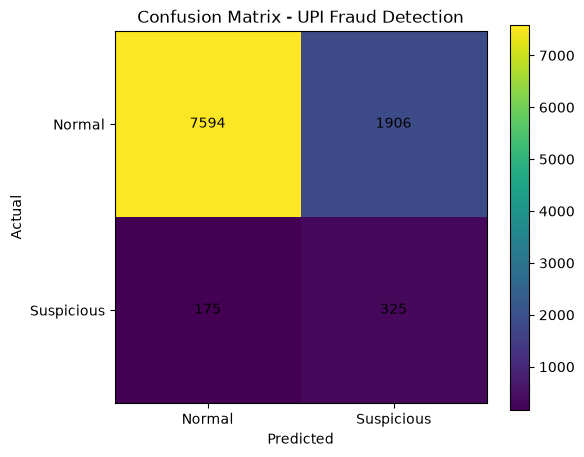

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - UPI Fraud Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Normal", "Suspicious"])
plt.yticks([0, 1], ["Normal", "Suspicious"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [78]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Suspicious"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.80      0.88      9500
  Suspicious       0.15      0.65      0.24       500

    accuracy                           0.79     10000
   macro avg       0.56      0.72      0.56     10000
weighted avg       0.94      0.79      0.85     10000



In [79]:
tn, fp, fn, tp = cm.ravel()

false_positive_rate = fp / (fp + tn)

print(f"False Positive Rate: {false_positive_rate:.4f}")
print(f"False Positive Rate: {false_positive_rate * 100:.2f}%")

False Positive Rate: 0.2006
False Positive Rate: 20.06%


In [80]:
detection_rate = tp / (tp + fn)

print(
    f"Suspicious Transaction Detection Rate: "
    f"{detection_rate * 100:.2f}%"
)

Suspicious Transaction Detection Rate: 65.00%


In [81]:
performance_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positive Rate"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        false_positive_rate
    ]
})

performance_summary

,Metric,Score
0,Accuracy,0.791900
1,Precision,0.145675
2,Recall,0.650000
3,F1 Score,0.238008
4,False Positive Rate,0.200632


In [82]:
method_summary = pd.DataFrame({
    "Method": [
        "IQR",
        "Isolation Forest",
        "Combined Risk Model"
    ],
    "Anomalies_Flagged": [
        df["iqr_anomaly"].sum(),
        df["isolation_anomaly"].sum(),
        df["is_suspicious"].sum()
    ]
})

method_summary

,Method,Anomalies_Flagged
0,IQR,825
1,Isolation Forest,500
2,Combined Risk Model,2231


In [83]:
import os

os.makedirs("../data/processed", exist_ok=True)

print("Processed data folder ready.")

Processed data folder ready.


In [84]:
processed_path = "../data/processed/features.csv"

df.to_csv(
    processed_path,
    index=False
)

print("Processed dataset saved successfully.")
print("Path:", processed_path)

Processed dataset saved successfully.
Path: ../data/processed/features.csv


In [85]:
print("Final dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Final dataset shape: (10000, 43)

Columns:
['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount', 'merchant_category', 'transaction_type', 'location', 'device_type', 'upi_channel', 'hour', 'day_of_week', 'is_weekend', 'is_late_night', 'amount_deviation', 'transactions_last_1h', 'recipient_repeat_count', 'previous_device', 'previous_location', 'device_changed', 'location_changed', 'fraud_label', 'user_avg_amount', 'user_median_amount', 'user_max_amount', 'user_transaction_count', 'iqr_anomaly', 'isolation_prediction', 'isolation_anomaly', 'isolation_score', 'transaction_hour', 'time_series_anomaly', 'burst_anomaly', 'risk_iqr', 'risk_isolation', 'risk_burst', 'risk_device', 'risk_location', 'risk_late_night', 'risk_time_series', 'risk_score', 'risk_level', 'is_suspicious']


In [86]:
final_summary = df.groupby("risk_level").agg(
    transactions=("transaction_id", "count"),
    average_amount=("amount", "mean"),
    average_risk_score=("risk_score", "mean"),
    suspicious_count=("is_suspicious", "sum")
)

final_summary

,transactions,average_amount,average_risk_score,suspicious_count
risk_level,,,,
Critical,60,3667.368000,81.583333,60
High,259,4970.461660,67.509653,259
Low,7769,492.126038,16.403656,0
Medium,1912,1097.659231,34.626046,1912


In [87]:
alerts_df = df[df["is_suspicious"] == 1].copy()

alerts_df = alerts_df.sort_values(
    "risk_score",
    ascending=False
)

print("Total alerts:", len(alerts_df))

Total alerts: 2231


In [88]:
alerts_df[[
    "transaction_id",
    "sender_id",
    "receiver_id",
    "amount",
    "risk_score",
    "risk_level",
    "iqr_anomaly",
    "isolation_anomaly",
    "burst_anomaly",
    "device_changed",
    "location_changed",
    "is_late_night"
]].head(20)

,transaction_id,sender_id,receiver_id,amount,risk_score,risk_level,iqr_anomaly,isolation_anomaly,burst_anomaly,device_changed,location_changed,is_late_night
8481,TXN_007856,USER_0855,USER_0436,1764.06,100,Critical,1,1,1,1,1,1
7436,TXN_004867,USER_0751,USER_0719,2475.13,95,Critical,1,1,1,1,1,0
9190,TXN_003854,USER_0922,USER_0785,2497.69,95,Critical,1,1,1,1,1,0
9420,TXN_000176,USER_0943,USER_0882,2484.96,95,Critical,1,1,1,1,1,0
5940,TXN_008268,USER_0601,USER_0824,3754.41,95,Critical,1,1,1,1,1,0
2147,TXN_008285,USER_0215,USER_0512,1737.87,95,Critical,1,1,1,1,1,0
1795,TXN_007924,USER_0181,USER_0408,2152.20,80,Critical,1,1,0,1,1,1
96,TXN_009426,USER_0010,USER_0237,3475.40,80,Critical,1,1,0,1,1,1
6712,TXN_006648,USER_0675,USER_0092,1992.72,80,Critical,1,1,0,1,1,1
1056,TXN_009367,USER_0110,USER_0139,8382.06,80,Critical,1,1,0,1,1,1


In [89]:
alerts_path = "../data/processed/alerts.csv"

alerts_df.to_csv(
    alerts_path,
    index=False
)

print("Alerts dataset saved successfully.")
print("Path:", alerts_path)

Alerts dataset saved successfully.
Path: ../data/processed/alerts.csv


In [90]:
model_metadata = {
    "model_features": model_features,
    "risk_threshold": 30,
    "risk_levels": {
        "Low": "0-29",
        "Medium": "30-59",
        "High": "60-79",
        "Critical": "80-100"
    }
}

joblib.dump(
    model_metadata,
    "../models/model_metadata.pkl"
)

print("Model metadata saved successfully.")

Model metadata saved successfully.


In [91]:
print("=== PROJECT FILE CHECK ===")

print("\nRaw data:")
print(os.listdir("../data/raw"))

print("\nProcessed data:")
print(os.listdir("../data/processed"))

print("\nModels:")
print(os.listdir("../models"))

=== PROJECT FILE CHECK ===

Raw data:
['upi_transactions.csv']

Processed data:
['alerts.csv', 'features.csv']

Models:
['isolation_forest.pkl', 'model_metadata.pkl']


In [92]:
print("========== UPI FRAUD DETECTION SUMMARY ==========")

print(f"Total transactions       : {len(df):,}")
print(f"Synthetic suspicious     : {df['fraud_label'].sum():,}")
print(f"IQR anomalies            : {df['iqr_anomaly'].sum():,}")
print(f"Isolation Forest anomalies: {df['isolation_anomaly'].sum():,}")
print(f"Final alerts             : {df['is_suspicious'].sum():,}")

print("\nRisk levels:")
print(df["risk_level"].value_counts())

print("\nModel Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

========== UPI FRAUD DETECTION SUMMARY ==========
Total transactions       : 10,000
Synthetic suspicious     : 500
IQR anomalies            : 825
Isolation Forest anomalies: 500
Final alerts             : 2,231

Risk levels:
risk_level
Low         7769
Medium      1912
High         259
Critical      60
Name: count, dtype: int64

Model Performance:
Accuracy : 0.7919
Precision: 0.1457
Recall   : 0.6500
F1 Score : 0.2380


In [93]:
signal_summary = pd.DataFrame({
    "Signal": [
        "IQR",
        "Isolation Forest",
        "Burst",
        "Device Change",
        "Location Change",
        "Late Night",
        "Time-Series"
    ],
    "Transactions Flagged": [
        df["iqr_anomaly"].sum(),
        df["isolation_anomaly"].sum(),
        df["burst_anomaly"].sum(),
        df["device_changed"].sum(),
        df["location_changed"].sum(),
        df["is_late_night"].sum(),
        df["time_series_anomaly"].sum()
    ]
})

signal_summary

,Signal,Transactions Flagged
0,IQR,825
1,Isolation Forest,500
2,Burst,100
3,Device Change,6054
4,Location Change,7876
5,Late Night,2591
6,Time-Series,0


In [94]:
signal_summary["Percentage"] = (
    signal_summary["Transactions Flagged"]
    / len(df) * 100
).round(2)

signal_summary

,Signal,Transactions Flagged,Percentage
0,IQR,825,8.25
1,Isolation Forest,500,5.00
2,Burst,100,1.00
3,Device Change,6054,60.54
4,Location Change,7876,78.76
5,Late Night,2591,25.91
6,Time-Series,0,0.00


In [95]:
signal_columns = [
    "iqr_anomaly",
    "isolation_anomaly",
    "burst_anomaly",
    "device_changed",
    "location_changed",
    "is_late_night",
    "time_series_anomaly"
]

df["number_of_signals"] = df[signal_columns].sum(axis=1)

print(
    df["number_of_signals"]
    .value_counts()
    .sort_index()
)

number_of_signals
0     927
1    2566
2    4489
3    1728
4     233
5      56
6       1
Name: count, dtype: int64


In [96]:
alert_signal_distribution = (
    df[df["is_suspicious"] == 1]["number_of_signals"]
    .value_counts()
    .sort_index()
)

alert_signal_distribution

number_of_signals
1       4
2     209
3    1728
4     233
5      56
6       1
Name: count, dtype: int64

In [97]:
signal_by_label = df.groupby("fraud_label")[signal_columns].mean() * 100

signal_by_label.round(2)

,iqr_anomaly,isolation_anomaly,burst_anomaly,device_changed,location_changed,is_late_night,time_series_anomaly
fraud_label,,,,,,,
0,7.17,3.42,0.0,60.09,78.41,25.09,0.0
1,28.80,35.00,20.0,69.00,85.40,41.40,0.0


In [98]:
risk_by_label = df.groupby("fraud_label")["risk_score"].agg(
    ["count", "mean", "median", "min", "max"]
)

risk_by_label

,count,mean,median,min,max
fraud_label,,,,,
0,9500,20.57,25.0,0,80
1,500,41.22,30.0,0,100


In [99]:
df[df["fraud_label"] == 0]["risk_score"].describe()

count    9500.000000
mean       20.570000
std        12.891877
min         0.000000
25%        10.000000
50%        25.000000
75%        25.000000
max        80.000000
Name: risk_score, dtype: float64

In [100]:
df[df["fraud_label"] == 1]["risk_score"].describe()

count    500.000000
mean      41.220000
std       22.881405
min        0.000000
25%       25.000000
50%       30.000000
75%       60.000000
max      100.000000
Name: risk_score, dtype: float64

In [101]:
score_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

df["risk_score_range"] = pd.cut(
    df["risk_score"],
    bins=score_bins,
    include_lowest=True
)

score_analysis = pd.crosstab(
    df["risk_score_range"],
    df["fraud_label"],
    normalize="index"
) * 100

score_analysis.round(2)

fraud_label,0,1
risk_score_range,,
"(-0.001, 10.0]",98.99,1.01
"(10.0, 20.0]",95.58,4.42
"(20.0, 30.0]",96.10,3.90
"(30.0, 40.0]",95.65,4.35
"(40.0, 50.0]",86.23,13.77
"(50.0, 60.0]",62.92,37.08
"(60.0, 70.0]",65.00,35.00
"(70.0, 80.0]",44.14,55.86
"(90.0, 100.0]",0.00,100.00


In [102]:
false_positives = df[
    (df["fraud_label"] == 0) &
    (df["is_suspicious"] == 1)
].copy()

print("False positives:", len(false_positives))

false_positives[[
    "transaction_id",
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "device_changed",
    "location_changed",
    "is_late_night",
    "iqr_anomaly",
    "isolation_anomaly",
    "burst_anomaly",
    "time_series_anomaly",
    "risk_score",
    "risk_level"
]].sort_values(
    "risk_score",
    ascending=False
).head(20)

False positives: 1906


,transaction_id,amount,amount_deviation,transactions_last_1h,device_changed,location_changed,is_late_night,iqr_anomaly,isolation_anomaly,burst_anomaly,time_series_anomaly,risk_score,risk_level
5557,TXN_003550,5045.56,4.403347,0.0,1,1,1,1,1,0,0,80,Critical
294,TXN_008162,5109.76,5.620848,0.0,1,1,1,1,1,0,0,80,Critical
1795,TXN_007924,2152.20,2.341581,1.0,1,1,1,1,1,0,0,80,Critical
3901,TXN_000807,2782.52,2.686716,1.0,1,1,1,1,1,0,0,80,Critical
1152,TXN_003812,5096.10,5.834800,0.0,1,1,1,1,1,0,0,80,Critical
697,TXN_006698,5216.01,4.153643,0.0,1,1,1,1,1,0,0,80,Critical
3239,TXN_002170,6979.81,4.160433,0.0,1,1,1,1,1,0,0,80,Critical
5334,TXN_005155,4395.98,5.301599,0.0,1,1,1,1,1,0,0,80,Critical
23,TXN_009425,4075.97,3.355042,0.0,1,1,1,1,1,0,0,80,Critical
8383,TXN_009311,2762.36,3.342027,0.0,1,1,1,1,1,0,0,80,Critical


In [103]:
true_positives = df[
    (df["fraud_label"] == 1) &
    (df["is_suspicious"] == 1)
].copy()

print("True positives:", len(true_positives))

true_positives[[
    "transaction_id",
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "device_changed",
    "location_changed",
    "is_late_night",
    "iqr_anomaly",
    "isolation_anomaly",
    "burst_anomaly",
    "time_series_anomaly",
    "risk_score",
    "risk_level"
]].sort_values(
    "risk_score",
    ascending=False
).head(20)

True positives: 325


,transaction_id,amount,amount_deviation,transactions_last_1h,device_changed,location_changed,is_late_night,iqr_anomaly,isolation_anomaly,burst_anomaly,time_series_anomaly,risk_score,risk_level
8481,TXN_007856,1764.06,3.529168,18.0,1,1,1,1,1,1,0,100,Critical
7436,TXN_004867,2475.13,4.397615,18.0,1,1,0,1,1,1,0,95,Critical
9190,TXN_003854,2497.69,1.027832,8.0,1,1,0,1,1,1,0,95,Critical
9420,TXN_000176,2484.96,3.226204,16.0,1,1,0,1,1,1,0,95,Critical
5940,TXN_008268,3754.41,3.935661,19.0,1,1,0,1,1,1,0,95,Critical
2147,TXN_008285,1737.87,2.526429,15.0,1,1,0,1,1,1,0,95,Critical
8517,TXN_009626,2107.58,4.673581,9.0,0,1,0,1,1,1,0,80,Critical
1056,TXN_009367,8382.06,3.767448,0.0,1,1,1,1,1,0,0,80,Critical
8260,TXN_006382,311.06,0.626156,11.0,1,1,1,0,1,1,0,80,Critical
8537,TXN_002124,314.42,1.350808,18.0,1,1,1,0,1,1,0,80,Critical


In [104]:
current_cm = confusion_matrix(
    df["fraud_label"],
    df["is_suspicious"]
)

tn, fp, fn, tp = current_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 7594
False Positives: 1906
False Negatives: 175
True Positives : 325


In [105]:
alert_precision = tp / (tp + fp)

print(
    f"Current alert precision: {alert_precision * 100:.2f}%"
)

Current alert precision: 14.57%


In [106]:
missed_suspicious = df[
    (df["fraud_label"] == 1) &
    (df["is_suspicious"] == 0)
]

print(
    "Suspicious transactions missed:",
    len(missed_suspicious)
)

missed_suspicious[[
    "transaction_id",
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "device_changed",
    "location_changed",
    "is_late_night",
    "iqr_anomaly",
    "isolation_anomaly",
    "risk_score"
]].head(20)

Suspicious transactions missed: 175


,transaction_id,amount,amount_deviation,transactions_last_1h,device_changed,location_changed,is_late_night,iqr_anomaly,isolation_anomaly,risk_score
3,TXN_001586,109.54,0.208601,0.0,1,1,0,0,0,25
101,TXN_002474,71.82,0.081180,0.0,1,1,0,0,0,25
106,TXN_001950,390.27,0.139543,0.0,1,0,1,0,0,20
251,TXN_006017,1510.51,1.959684,0.0,1,1,0,0,0,25
259,TXN_009944,1021.85,1.325713,0.0,0,1,1,0,0,15
263,TXN_004050,265.44,0.432677,0.0,1,1,0,0,0,25
303,TXN_002260,213.04,0.379713,0.0,0,1,1,0,0,15
321,TXN_001060,437.43,0.846670,0.0,0,0,0,0,0,0
333,TXN_008661,62.72,0.075312,0.0,1,1,0,0,0,25
360,TXN_002026,213.01,0.248692,0.0,0,1,1,0,0,15


In [107]:
baseline_metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "False Positive Rate": false_positive_rate
}

baseline_metrics

{'Accuracy': 0.7919,
 'Precision': 0.14567458538771852,
 'Recall': 0.65,
 'F1 Score': 0.2380080556572684,
 'False Positive Rate': np.float64(0.2006315789473684)}

In [108]:
df["improved_risk_score"] = (
    df["iqr_anomaly"] * 15 +
    df["isolation_anomaly"] * 35 +
    df["burst_anomaly"] * 25 +
    df["device_changed"] * 5 +
    df["location_changed"] * 5 +
    df["is_late_night"] * 5 +
    df["time_series_anomaly"] * 10
)

df["improved_risk_score"] = (
    df["improved_risk_score"].clip(upper=100)
)

print(df["improved_risk_score"].describe())

count    10000.000000
mean        11.498000
std         11.859809
min          0.000000
25%          5.000000
50%         10.000000
75%         10.000000
max         90.000000
Name: improved_risk_score, dtype: float64


In [109]:
df["improved_is_suspicious"] = (
    df["improved_risk_score"] >= 50
).astype(int)

print(
    "Improved alerts:",
    df["improved_is_suspicious"].sum()
)

print(
    "Alert percentage:",
    round(
        df["improved_is_suspicious"].mean() * 100,
        2
    ),
    "%"
)

Improved alerts: 399
Alert percentage: 3.99 %


In [110]:
improved_accuracy = accuracy_score(
    df["fraud_label"],
    df["improved_is_suspicious"]
)

improved_precision = precision_score(
    df["fraud_label"],
    df["improved_is_suspicious"],
    zero_division=0
)

improved_recall = recall_score(
    df["fraud_label"],
    df["improved_is_suspicious"],
    zero_division=0
)

improved_f1 = f1_score(
    df["fraud_label"],
    df["improved_is_suspicious"],
    zero_division=0
)

print(f"Accuracy : {improved_accuracy:.4f}")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall   : {improved_recall:.4f}")
print(f"F1 Score : {improved_f1:.4f}")

Accuracy : 0.9447
Precision: 0.4336
Recall   : 0.3460
F1 Score : 0.3849


In [111]:
improved_cm = confusion_matrix(
    df["fraud_label"],
    df["improved_is_suspicious"]
)

print(improved_cm)

[[9274  226]
 [ 327  173]]


In [112]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Baseline": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Improved": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1
    ]
})

comparison

,Metric,Baseline,Improved
0,Accuracy,0.791900,0.944700
1,Precision,0.145675,0.433584
2,Recall,0.650000,0.346000
3,F1 Score,0.238008,0.384872


In [113]:
threshold_results = []

for threshold in [30, 40, 50, 60, 70, 80]:
    
    predictions = (
        df["improved_risk_score"] >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Alerts": predictions.sum(),
        "Precision": precision_score(
            df["fraud_label"],
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            df["fraud_label"],
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            df["fraud_label"],
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Alerts,Precision,Recall,F1 Score
0,30,581,0.3391,0.394,0.3645
1,40,496,0.3528,0.350,0.3514
2,50,399,0.4336,0.346,0.3849
3,60,244,0.5533,0.270,0.3629
4,70,59,1.0000,0.118,0.2111
5,80,9,1.0000,0.018,0.0354


In [114]:
threshold_results["False Positive Rate"] = 0.0

for i, threshold in enumerate(
    threshold_results["Threshold"]
):
    
    predictions = (
        df["improved_risk_score"] >= threshold
    ).astype(int)
    
    cm_temp = confusion_matrix(
        df["fraud_label"],
        predictions
    )
    
    tn_temp, fp_temp, fn_temp, tp_temp = cm_temp.ravel()
    
    threshold_results.loc[
        i,
        "False Positive Rate"
    ] = fp_temp / (fp_temp + tn_temp)

threshold_results.round(4)

,Threshold,Alerts,Precision,Recall,F1 Score,False Positive Rate
0,30,581,0.3391,0.394,0.3645,0.0404
1,40,496,0.3528,0.350,0.3514,0.0338
2,50,399,0.4336,0.346,0.3849,0.0238
3,60,244,0.5533,0.270,0.3629,0.0115
4,70,59,1.0000,0.118,0.2111,0.0000
5,80,9,1.0000,0.018,0.0354,0.0000


In [115]:
threshold_results.sort_values(
    "F1 Score",
    ascending=False
).round(4)

,Threshold,Alerts,Precision,Recall,F1 Score,False Positive Rate
2,50,399,0.4336,0.346,0.3849,0.0238
0,30,581,0.3391,0.394,0.3645,0.0404
3,60,244,0.5533,0.270,0.3629,0.0115
1,40,496,0.3528,0.350,0.3514,0.0338
4,70,59,1.0000,0.118,0.2111,0.0000
5,80,9,1.0000,0.018,0.0354,0.0000


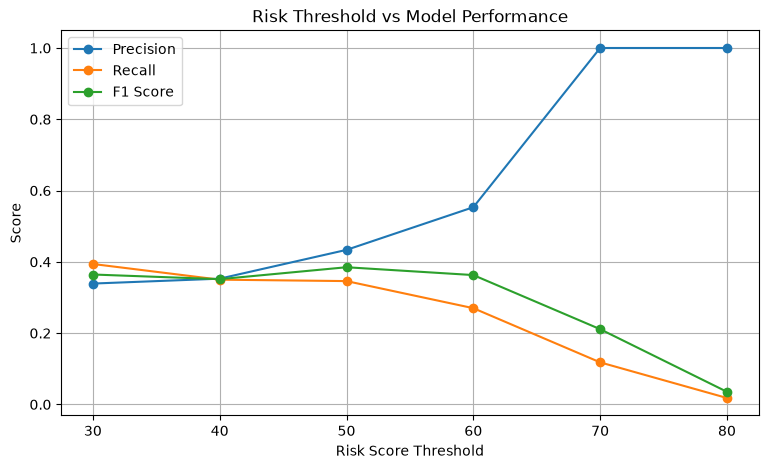

In [116]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Risk Score Threshold")
plt.ylabel("Score")
plt.title("Risk Threshold vs Model Performance")
plt.legend()
plt.grid(True)

plt.show()

In [117]:
FINAL_THRESHOLD = 50

df["final_risk_score"] = df["improved_risk_score"]

df["final_is_suspicious"] = (
    df["final_risk_score"] >= FINAL_THRESHOLD
).astype(int)

print("Final threshold:", FINAL_THRESHOLD)
print("Final alerts:", df["final_is_suspicious"].sum())

Final threshold: 50
Final alerts: 399


In [118]:
final_accuracy = accuracy_score(
    df["fraud_label"],
    df["final_is_suspicious"]
)

final_precision = precision_score(
    df["fraud_label"],
    df["final_is_suspicious"],
    zero_division=0
)

final_recall = recall_score(
    df["fraud_label"],
    df["final_is_suspicious"],
    zero_division=0
)

final_f1 = f1_score(
    df["fraud_label"],
    df["final_is_suspicious"],
    zero_division=0
)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

Accuracy : 0.9447
Precision: 0.4336
Recall   : 0.3460
F1 Score : 0.3849


In [119]:
final_cm = confusion_matrix(
    df["fraud_label"],
    df["final_is_suspicious"]
)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[9274  226]
 [ 327  173]]


In [120]:
tn, fp, fn, tp = final_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nTotal transactions:", len(df))
print("Final alerts:", df["final_is_suspicious"].sum())
print(
    "Alert rate:",
    round(df["final_is_suspicious"].mean() * 100, 2),
    "%"
)

True Negatives : 9274
False Positives: 226
False Negatives: 327
True Positives : 173

Total transactions: 10000
Final alerts: 399
Alert rate: 3.99 %


In [121]:
def assign_final_risk_level(score):
    if score < 30:
        return "Low"
    elif score < 50:
        return "Medium"
    elif score < 70:
        return "High"
    else:
        return "Critical"

df["final_risk_level"] = (
    df["final_risk_score"]
    .apply(assign_final_risk_level)
)

print(df["final_risk_level"].value_counts())

final_risk_level
Low         9419
High         340
Medium       182
Critical      59
Name: count, dtype: int64


In [122]:
df.sort_values(
    "final_risk_score",
    ascending=False
)[[
    "transaction_id",
    "sender_id",
    "receiver_id",
    "amount",
    "amount_deviation",
    "transactions_last_1h",
    "device_changed",
    "location_changed",
    "is_late_night",
    "iqr_anomaly",
    "isolation_anomaly",
    "burst_anomaly",
    "time_series_anomaly",
    "final_risk_score",
    "final_risk_level",
    "fraud_label"
]].head(20)

,transaction_id,sender_id,receiver_id,amount,amount_deviation,transactions_last_1h,device_changed,location_changed,is_late_night,iqr_anomaly,isolation_anomaly,burst_anomaly,time_series_anomaly,final_risk_score,final_risk_level,fraud_label
8481,TXN_007856,USER_0855,USER_0436,1764.06,3.529168,18.0,1,1,1,1,1,1,0,90,Critical,1
7436,TXN_004867,USER_0751,USER_0719,2475.13,4.397615,18.0,1,1,0,1,1,1,0,85,Critical,1
9190,TXN_003854,USER_0922,USER_0785,2497.69,1.027832,8.0,1,1,0,1,1,1,0,85,Critical,1
5940,TXN_008268,USER_0601,USER_0824,3754.41,3.935661,19.0,1,1,0,1,1,1,0,85,Critical,1
9420,TXN_000176,USER_0943,USER_0882,2484.96,3.226204,16.0,1,1,0,1,1,1,0,85,Critical,1
2147,TXN_008285,USER_0215,USER_0512,1737.87,2.526429,15.0,1,1,0,1,1,1,0,85,Critical,1
9275,TXN_009090,USER_0929,USER_0335,2562.74,3.052225,6.0,0,1,0,1,1,1,0,80,Critical,1
8517,TXN_009626,USER_0858,USER_0748,2107.58,4.673581,9.0,0,1,0,1,1,1,0,80,Critical,1
2029,TXN_006089,USER_0203,USER_0293,2390.73,2.524234,13.0,0,1,0,1,1,1,0,80,Critical,1
5266,TXN_008147,USER_0532,USER_0241,295.76,0.385059,11.0,1,1,1,0,1,1,0,75,Critical,1


In [126]:
import os
import json
import joblib

PROJECT_DIR = r"D:\UPI-Fraud-Detection"

RAW_DIR = os.path.join(PROJECT_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Raw data:", RAW_DIR)
print("Processed data:", PROCESSED_DIR)
print("Models:", MODELS_DIR)

Project: D:\UPI-Fraud-Detection
Raw data: D:\UPI-Fraud-Detection\data\raw
Processed data: D:\UPI-Fraud-Detection\data\processed
Models: D:\UPI-Fraud-Detection\models


In [127]:
features_path = os.path.join(
    PROCESSED_DIR,
    "features.csv"
)

df.to_csv(
    features_path,
    index=False
)

print("Saved successfully:")
print(features_path)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Saved successfully:
D:\UPI-Fraud-Detection\data\processed\features.csv
Rows: 10000
Columns: 50


In [125]:
final_alerts_df = df[
    df["final_is_suspicious"] == 1
].copy()

final_alerts_df = final_alerts_df.sort_values(
    "final_risk_score",
    ascending=False
).reset_index(drop=True)

print("Final alerts:", len(final_alerts_df))
print()

final_alerts_df.head(10)

Final alerts: 399



,transaction_id,timestamp,sender_id,receiver_id,amount,merchant_category,transaction_type,location,device_type,upi_channel,...,risk_score,risk_level,is_suspicious,number_of_signals,risk_score_range,improved_risk_score,improved_is_suspicious,final_risk_score,final_is_suspicious,final_risk_level
0,TXN_007856,2026-09-19 00:49:42.793653,USER_0855,USER_0436,1764.06,Travel,P2P,Chennai,Web,Other,...,100,Critical,1,6,"(90.0, 100.0]",90,1,90,1,Critical
1,TXN_003854,2026-09-16 06:07:42.793653,USER_0922,USER_0785,2497.69,Education,P2P,Kolkata,Android,BHIM,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
2,TXN_008285,2026-09-19 07:58:42.793653,USER_0215,USER_0512,1737.87,Entertainment,P2P,Delhi,Web,Google Pay,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
3,TXN_004867,2026-09-16 23:00:42.793653,USER_0751,USER_0719,2475.13,Travel,P2M,Pune,Android,PhonePe,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
4,TXN_000176,2026-09-13 16:49:42.793653,USER_0943,USER_0882,2484.96,Shopping,P2P,Hyderabad,iOS,PhonePe,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
5,TXN_008268,2026-09-19 07:41:42.793653,USER_0601,USER_0824,3754.41,Bills,P2M,Kolkata,iOS,BHIM,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
6,TXN_006089,2026-09-17 19:22:42.793653,USER_0203,USER_0293,2390.73,Travel,P2P,Bangalore,Web,Google Pay,...,80,Critical,1,4,"(70.0, 80.0]",80,1,80,1,Critical
7,TXN_009626,2026-09-20 06:19:42.793653,USER_0858,USER_0748,2107.58,Shopping,P2P,Chennai,Android,BHIM,...,80,Critical,1,4,"(70.0, 80.0]",80,1,80,1,Critical
8,TXN_009090,2026-09-19 21:23:42.793653,USER_0929,USER_0335,2562.74,Shopping,P2P,Bangalore,iOS,Google Pay,...,80,Critical,1,4,"(70.0, 80.0]",80,1,80,1,Critical
9,TXN_009390,2026-09-20 02:23:42.793653,USER_0789,USER_0745,852.54,Bills,P2P,Delhi,Web,BHIM,...,80,Critical,1,5,"(70.0, 80.0]",75,1,75,1,Critical


In [128]:
alerts_path = os.path.join(
    PROCESSED_DIR,
    "alerts.csv"
)

final_alerts_df.to_csv(
    alerts_path,
    index=False
)

print("Saved successfully:")
print(alerts_path)

Saved successfully:
D:\UPI-Fraud-Detection\data\processed\alerts.csv


In [129]:
final_metadata = {
    "model_features": model_features,
    "final_threshold": FINAL_THRESHOLD,
    "risk_weights": {
        "iqr_anomaly": 15,
        "isolation_anomaly": 35,
        "burst_anomaly": 25,
        "device_changed": 5,
        "location_changed": 5,
        "is_late_night": 5,
        "time_series_anomaly": 10
    },
    "isolation_forest_contamination": 0.05,
    "total_transactions": len(df),
    "synthetic_suspicious_transactions": int(
        df["fraud_label"].sum()
    )
}

print(final_metadata)

{'model_features': ['amount', 'amount_deviation', 'transactions_last_1h', 'recipient_repeat_count', 'device_changed', 'location_changed', 'is_late_night', 'is_weekend'], 'final_threshold': 50, 'risk_weights': {'iqr_anomaly': 15, 'isolation_anomaly': 35, 'burst_anomaly': 25, 'device_changed': 5, 'location_changed': 5, 'is_late_night': 5, 'time_series_anomaly': 10}, 'isolation_forest_contamination': 0.05, 'total_transactions': 10000, 'synthetic_suspicious_transactions': 500}


In [130]:
metadata_path = os.path.join(
    MODELS_DIR,
    "model_metadata.pkl"
)

joblib.dump(
    final_metadata,
    metadata_path
)

print("Saved successfully:")
print(metadata_path)

Saved successfully:
D:\UPI-Fraud-Detection\models\model_metadata.pkl


In [131]:
iqr_metadata = {
    "Q1": float(Q1),
    "Q3": float(Q3),
    "IQR": float(IQR),
    "lower_bound": float(lower_bound),
    "upper_bound": float(upper_bound)
}

iqr_path = os.path.join(
    MODELS_DIR,
    "iqr_metadata.pkl"
)

joblib.dump(
    iqr_metadata,
    iqr_path
)

print("IQR metadata saved:")
print(iqr_path)

print()
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

IQR metadata saved:
D:\UPI-Fraud-Detection\models\iqr_metadata.pkl

Lower bound: -715.68375
Upper bound: 1734.1062499999998


In [132]:
saved_files = [
    os.path.join(
        RAW_DIR,
        "upi_transactions.csv"
    ),
    os.path.join(
        PROCESSED_DIR,
        "features.csv"
    ),
    os.path.join(
        PROCESSED_DIR,
        "alerts.csv"
    ),
    os.path.join(
        MODELS_DIR,
        "isolation_forest.pkl"
    ),
    os.path.join(
        MODELS_DIR,
        "model_metadata.pkl"
    ),
    os.path.join(
        MODELS_DIR,
        "iqr_metadata.pkl"
    )
]

print("========== SAVED FILE VERIFICATION ==========")

for file_path in saved_files:
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"✓ {file_path}")
        print(f"  Size: {size_kb:.1f} KB")
    else:
        print(f"✗ NOT FOUND: {file_path}")

========== SAVED FILE VERIFICATION ==========
✓ D:\UPI-Fraud-Detection\data\raw\upi_transactions.csv
  Size: 1802.8 KB
✓ D:\UPI-Fraud-Detection\data\processed\features.csv
  Size: 2847.2 KB
✓ D:\UPI-Fraud-Detection\data\processed\alerts.csv
  Size: 116.5 KB
✗ NOT FOUND: D:\UPI-Fraud-Detection\models\isolation_forest.pkl
✓ D:\UPI-Fraud-Detection\models\model_metadata.pkl
  Size: 0.4 KB
✓ D:\UPI-Fraud-Detection\models\iqr_metadata.pkl
  Size: 0.1 KB


In [133]:
print("Isolation Forest model:", isolation_model)
print("Model type:", type(isolation_model))

Isolation Forest model: IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
Model type: <class 'sklearn.ensemble._iforest.IsolationForest'>


In [134]:
isolation_model_path = r"D:\UPI-Fraud-Detection\models\isolation_forest.pkl"

joblib.dump(
    isolation_model,
    isolation_model_path
)

print("Isolation Forest saved successfully:")
print(isolation_model_path)

Isolation Forest saved successfully:
D:\UPI-Fraud-Detection\models\isolation_forest.pkl


In [135]:
import os

if os.path.exists(isolation_model_path):
    size_kb = os.path.getsize(isolation_model_path) / 1024
    
    print("✓ Model file found")
    print("Path:", isolation_model_path)
    print(f"Size: {size_kb:.1f} KB")
else:
    print("✗ Model file still not found")

✓ Model file found
Path: D:\UPI-Fraud-Detection\models\isolation_forest.pkl
Size: 2405.0 KB


In [136]:
print("========== FINAL MODEL VERIFICATION ==========")

model_files = [
    r"D:\UPI-Fraud-Detection\models\isolation_forest.pkl",
    r"D:\UPI-Fraud-Detection\models\model_metadata.pkl",
    r"D:\UPI-Fraud-Detection\models\iqr_metadata.pkl"
]

for file_path in model_files:
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"✓ {file_path}")
        print(f"  Size: {size_kb:.1f} KB")
    else:
        print(f"✗ NOT FOUND: {file_path}")

========== FINAL MODEL VERIFICATION ==========
✓ D:\UPI-Fraud-Detection\models\isolation_forest.pkl
  Size: 2405.0 KB
✓ D:\UPI-Fraud-Detection\models\model_metadata.pkl
  Size: 0.4 KB
✓ D:\UPI-Fraud-Detection\models\iqr_metadata.pkl
  Size: 0.1 KB


In [137]:
!pip install fastapi uvicorn pydantic

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 4.8 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.0 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 4.2 MB/s  0:00:00

   ---- ----------------------------------- 1/9 [pydantic-core]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   ----------------- ---------------------- 4/9 [annotated-doc]
   ---------------------- ----------------- 5/9 [uvicorn]
   ---------------------- ----------------- 5/9 [uvicorn]
   ---------------------- ----------------- 5/9 [uvicorn]
   ---------------------- ----------------- 5/9 [uvicorn]
   ---------------------- ----------------- 5/9 [uvicorn]
   ---------------------- ----------------- 5/9 [uvicorn]
   ---------------------- ----------------- 5/9 [uvicorn]
   

In [139]:
import os

PROJECT_DIR = r"D:\UPI-Fraud-Detection"
API_DIR = r"D:\UPI-Fraud-Detection\api"

os.makedirs(API_DIR, exist_ok=True)

print("API folder created:")
print(API_DIR)

API folder created:
D:\UPI-Fraud-Detection\api


In [140]:
print("Project exists:", os.path.exists(PROJECT_DIR))
print("API folder exists:", os.path.exists(API_DIR))

print("\nAPI location:")
print(API_DIR)

Project exists: True
API folder exists: True

API location:
D:\UPI-Fraud-Detection\api


In [141]:
MODEL_DIR = r"D:\UPI-Fraud-Detection\models"

required_models = [
    r"D:\UPI-Fraud-Detection\models\isolation_forest.pkl",
    r"D:\UPI-Fraud-Detection\models\model_metadata.pkl",
    r"D:\UPI-Fraud-Detection\models\iqr_metadata.pkl"
]

print("========== MODEL FILE CHECK ==========")

for path in required_models:
    if os.path.exists(path):
        print("✓", path)
    else:
        print("✗ MISSING:", path)

========== MODEL FILE CHECK ==========
✓ D:\UPI-Fraud-Detection\models\isolation_forest.pkl
✓ D:\UPI-Fraud-Detection\models\model_metadata.pkl
✓ D:\UPI-Fraud-Detection\models\iqr_metadata.pkl


In [142]:
PROCESSED_DIR = r"D:\UPI-Fraud-Detection\data\processed"

required_data = [
    r"D:\UPI-Fraud-Detection\data\processed\features.csv",
    r"D:\UPI-Fraud-Detection\data\processed\alerts.csv"
]

print("========== DATA FILE CHECK ==========")

for path in required_data:
    if os.path.exists(path):
        print("✓", path)
    else:
        print("✗ MISSING:", path)

========== DATA FILE CHECK ==========
✓ D:\UPI-Fraud-Detection\data\processed\features.csv
✓ D:\UPI-Fraud-Detection\data\processed\alerts.csv


In [143]:
import joblib

isolation_model_path = r"D:\UPI-Fraud-Detection\models\isolation_forest.pkl"

isolation_model = joblib.load(
    isolation_model_path
)

print("Isolation Forest loaded successfully.")
print(type(isolation_model))

Isolation Forest loaded successfully.
<class 'sklearn.ensemble._iforest.IsolationForest'>


In [144]:
metadata_path = r"D:\UPI-Fraud-Detection\models\model_metadata.pkl"

final_metadata = joblib.load(
    metadata_path
)

print("========== MODEL METADATA ==========")
print(final_metadata)

========== MODEL METADATA ==========
{'model_features': ['amount', 'amount_deviation', 'transactions_last_1h', 'recipient_repeat_count', 'device_changed', 'location_changed', 'is_late_night', 'is_weekend'], 'final_threshold': 50, 'risk_weights': {'iqr_anomaly': 15, 'isolation_anomaly': 35, 'burst_anomaly': 25, 'device_changed': 5, 'location_changed': 5, 'is_late_night': 5, 'time_series_anomaly': 10}, 'isolation_forest_contamination': 0.05, 'total_transactions': 10000, 'synthetic_suspicious_transactions': 500}


In [146]:
iqr_metadata_path = r"D:\UPI-Fraud-Detection\models\iqr_metadata.pkl"

iqr_metadata = joblib.load(
    iqr_metadata_path
)

print("========== IQR METADATA ==========")
print(iqr_metadata)

========== IQR METADATA ==========
{'Q1': 202.98749999999998, 'Q3': 815.435, 'IQR': 612.4475, 'lower_bound': -715.68375, 'upper_bound': 1734.1062499999998}


In [147]:
alerts_path = r"D:\UPI-Fraud-Detection\data\processed\alerts.csv"

alerts_df = pd.read_csv(
    alerts_path
)

print("Alerts dataset loaded.")
print("Rows:", len(alerts_df))
print("Columns:", len(alerts_df.columns))

alerts_df.head(5)

Alerts dataset loaded.
Rows: 399
Columns: 50


,transaction_id,timestamp,sender_id,receiver_id,amount,merchant_category,transaction_type,location,device_type,upi_channel,...,risk_score,risk_level,is_suspicious,number_of_signals,risk_score_range,improved_risk_score,improved_is_suspicious,final_risk_score,final_is_suspicious,final_risk_level
0,TXN_007856,2026-09-19 00:49:42.793653,USER_0855,USER_0436,1764.06,Travel,P2P,Chennai,Web,Other,...,100,Critical,1,6,"(90.0, 100.0]",90,1,90,1,Critical
1,TXN_003854,2026-09-16 06:07:42.793653,USER_0922,USER_0785,2497.69,Education,P2P,Kolkata,Android,BHIM,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
2,TXN_008285,2026-09-19 07:58:42.793653,USER_0215,USER_0512,1737.87,Entertainment,P2P,Delhi,Web,Google Pay,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
3,TXN_004867,2026-09-16 23:00:42.793653,USER_0751,USER_0719,2475.13,Travel,P2M,Pune,Android,PhonePe,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical
4,TXN_000176,2026-09-13 16:49:42.793653,USER_0943,USER_0882,2484.96,Shopping,P2P,Hyderabad,iOS,PhonePe,...,95,Critical,1,5,"(90.0, 100.0]",85,1,85,1,Critical


In [148]:
features_path = r"D:\UPI-Fraud-Detection\data\processed\features.csv"

features_df = pd.read_csv(
    features_path
)

print("Features dataset loaded.")
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))

print("\nColumns:")
print(features_df.columns.tolist())

Features dataset loaded.
Rows: 10000
Columns: 50

Columns:
['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount', 'merchant_category', 'transaction_type', 'location', 'device_type', 'upi_channel', 'hour', 'day_of_week', 'is_weekend', 'is_late_night', 'amount_deviation', 'transactions_last_1h', 'recipient_repeat_count', 'previous_device', 'previous_location', 'device_changed', 'location_changed', 'fraud_label', 'user_avg_amount', 'user_median_amount', 'user_max_amount', 'user_transaction_count', 'iqr_anomaly', 'isolation_prediction', 'isolation_anomaly', 'isolation_score', 'transaction_hour', 'time_series_anomaly', 'burst_anomaly', 'risk_iqr', 'risk_isolation', 'risk_burst', 'risk_device', 'risk_location', 'risk_late_night', 'risk_time_series', 'risk_score', 'risk_level', 'is_suspicious', 'number_of_signals', 'risk_score_range', 'improved_risk_score', 'improved_is_suspicious', 'final_risk_score', 'final_is_suspicious', 'final_risk_level']


In [149]:
print("========== API SETUP VERIFICATION ==========")

print("\nProject:")
print(PROJECT_DIR)

print("\nAPI:")
print(API_DIR)

print("\nModels:")
print(MODEL_DIR)

print("\nProcessed data:")
print(PROCESSED_DIR)

print("\nIsolation Forest:")
print(type(isolation_model))

print("\nAlerts:")
print(len(alerts_df))

print("\nTransactions:")
print(len(features_df))

print("\nFinal threshold:")
print(final_metadata["final_threshold"])

print("\n✓ API prerequisites are ready.")

========== API SETUP VERIFICATION ==========

Project:
D:\UPI-Fraud-Detection

API:
D:\UPI-Fraud-Detection\api

Models:
D:\UPI-Fraud-Detection\models

Processed data:
D:\UPI-Fraud-Detection\data\processed

Isolation Forest:
<class 'sklearn.ensemble._iforest.IsolationForest'>

Alerts:
399

Transactions:
10000

Final threshold:
50

✓ API prerequisites are ready.


In [150]:
schemas_code = r'''
from pydantic import BaseModel, Field


class TransactionRequest(BaseModel):
    transaction_id: str = Field(..., description="Unique transaction ID")
    amount: float = Field(..., gt=0)
    amount_deviation: float = Field(..., ge=0)
    transactions_last_1h: int = Field(..., ge=0)
    recipient_repeat_count: int = Field(..., ge=0)
    device_changed: int = Field(..., ge=0, le=1)
    location_changed: int = Field(..., ge=0, le=1)
    is_late_night: int = Field(..., ge=0, le=1)
    is_weekend: int = Field(..., ge=0, le=1)


class PredictionResponse(BaseModel):
    transaction_id: str
    risk_score: float
    risk_level: str
    is_suspicious: bool
    reasons: list[str]
    isolation_anomaly: int
    iqr_anomaly: int
    burst_anomaly: int
'''
 
schemas_path = r"D:\UPI-Fraud-Detection\api\schemas.py"

with open(schemas_path, "w", encoding="utf-8") as f:
    f.write(schemas_code)

print("Created:")
print(schemas_path)

Created:
D:\UPI-Fraud-Detection\api\schemas.py


In [151]:
predictor_code = r'''
import os
import joblib
import pandas as pd


PROJECT_DIR = r"D:\UPI-Fraud-Detection"

MODEL_DIR = r"D:\UPI-Fraud-Detection\models"
DATA_DIR = r"D:\UPI-Fraud-Detection\data\processed"

ISOLATION_MODEL_PATH = (
    r"D:\UPI-Fraud-Detection\models\isolation_forest.pkl"
)

MODEL_METADATA_PATH = (
    r"D:\UPI-Fraud-Detection\models\model_metadata.pkl"
)

IQR_METADATA_PATH = (
    r"D:\UPI-Fraud-Detection\models\iqr_metadata.pkl"
)

FEATURES_PATH = (
    r"D:\UPI-Fraud-Detection\data\processed\features.csv"
)

ALERTS_PATH = (
    r"D:\UPI-Fraud-Detection\data\processed\alerts.csv"
)


isolation_model = joblib.load(
    ISOLATION_MODEL_PATH
)

model_metadata = joblib.load(
    MODEL_METADATA_PATH
)

iqr_metadata = joblib.load(
    IQR_METADATA_PATH
)

features_df = pd.read_csv(
    FEATURES_PATH
)

alerts_df = pd.read_csv(
    ALERTS_PATH
)


MODEL_FEATURES = model_metadata["model_features"]
FINAL_THRESHOLD = model_metadata["final_threshold"]
RISK_WEIGHTS = model_metadata["risk_weights"]

LOWER_BOUND = iqr_metadata["lower_bound"]
UPPER_BOUND = iqr_metadata["upper_bound"]


def calculate_prediction(transaction):
    data = {
        "amount": transaction.amount,
        "amount_deviation": transaction.amount_deviation,
        "transactions_last_1h": transaction.transactions_last_1h,
        "recipient_repeat_count": transaction.recipient_repeat_count,
        "device_changed": transaction.device_changed,
        "location_changed": transaction.location_changed,
        "is_late_night": transaction.is_late_night,
        "is_weekend": transaction.is_weekend
    }

    input_df = pd.DataFrame([data])

    isolation_prediction = isolation_model.predict(
        input_df[MODEL_FEATURES]
    )[0]

    isolation_anomaly = int(
        isolation_prediction == -1
    )

    iqr_anomaly = int(
        transaction.amount < LOWER_BOUND
        or transaction.amount > UPPER_BOUND
    )

    burst_anomaly = int(
        transaction.transactions_last_1h >= 5
    )

    risk_score = (
        iqr_anomaly * RISK_WEIGHTS["iqr_anomaly"]
        + isolation_anomaly * RISK_WEIGHTS["isolation_anomaly"]
        + burst_anomaly * RISK_WEIGHTS["burst_anomaly"]
        + transaction.device_changed * RISK_WEIGHTS["device_changed"]
        + transaction.location_changed * RISK_WEIGHTS["location_changed"]
        + transaction.is_late_night * RISK_WEIGHTS["is_late_night"]
    )

    risk_score = min(risk_score, 100)

    if risk_score < 30:
        risk_level = "Low"
    elif risk_score < 50:
        risk_level = "Medium"
    elif risk_score < 70:
        risk_level = "High"
    else:
        risk_level = "Critical"

    is_suspicious = (
        risk_score >= FINAL_THRESHOLD
    )

    reasons = []

    if iqr_anomaly:
        reasons.append("Unusually high or low transaction amount")

    if isolation_anomaly:
        reasons.append("Isolation Forest detected anomalous behavior")

    if burst_anomaly:
        reasons.append("High transaction frequency within 1 hour")

    if transaction.device_changed:
        reasons.append("New or changed device detected")

    if transaction.location_changed:
        reasons.append("Location change detected")

    if transaction.is_late_night:
        reasons.append("Late-night transaction")

    if not reasons:
        reasons.append("No major suspicious signals detected")

    return {
        "transaction_id": transaction.transaction_id,
        "risk_score": float(risk_score),
        "risk_level": risk_level,
        "is_suspicious": bool(is_suspicious),
        "reasons": reasons,
        "isolation_anomaly": isolation_anomaly,
        "iqr_anomaly": iqr_anomaly,
        "burst_anomaly": burst_anomaly
    }
'''
 
predictor_path = r"D:\UPI-Fraud-Detection\api\predictor.py"

with open(predictor_path, "w", encoding="utf-8") as f:
    f.write(predictor_code)

print("Created:")
print(predictor_path)

Created:
D:\UPI-Fraud-Detection\api\predictor.py


In [152]:
main_code = r'''
from fastapi import FastAPI, HTTPException

from schemas import (
    TransactionRequest,
    PredictionResponse
)

from predictor import (
    calculate_prediction,
    alerts_df,
    features_df
)


app = FastAPI(
    title="UPI Fraud Detection API",
    description="API for UPI transaction anomaly and fraud risk detection",
    version="1.0.0"
)


@app.get("/health")
def health_check():
    return {
        "status": "healthy",
        "service": "UPI Fraud Detection API"
    }


@app.post(
    "/predict",
    response_model=PredictionResponse
)
def predict_transaction(
    transaction: TransactionRequest
):
    return calculate_prediction(transaction)


@app.get("/alerts")
def get_alerts():
    return {
        "total_alerts": len(alerts_df),
        "alerts": alerts_df.to_dict(
            orient="records"
        )
    }


@app.get("/transaction/{transaction_id}")
def get_transaction(
    transaction_id: str
):
    result = features_df[
        features_df["transaction_id"].astype(str)
        == str(transaction_id)
    ]

    if result.empty:
        raise HTTPException(
            status_code=404,
            detail="Transaction not found"
        )

    return result.iloc[0].to_dict()


@app.get("/")
def root():
    return {
        "message": "UPI Fraud Detection API",
        "docs": "/docs",
        "health": "/health"
    }
'''
 
main_path = r"D:\UPI-Fraud-Detection\api\main.py"

with open(main_path, "w", encoding="utf-8") as f:
    f.write(main_code)

print("Created:")
print(main_path)

Created:
D:\UPI-Fraud-Detection\api\main.py


In [153]:
api_files = [
    r"D:\UPI-Fraud-Detection\api\schemas.py",
    r"D:\UPI-Fraud-Detection\api\predictor.py",
    r"D:\UPI-Fraud-Detection\api\main.py"
]

print("========== API FILE VERIFICATION ==========")

for file_path in api_files:
    if os.path.exists(file_path):
        size = os.path.getsize(file_path)
        print(f"✓ {file_path}")
        print(f"  Size: {size} bytes")
    else:
        print(f"✗ NOT FOUND: {file_path}")

========== API FILE VERIFICATION ==========
✓ D:\UPI-Fraud-Detection\api\schemas.py
  Size: 777 bytes
✓ D:\UPI-Fraud-Detection\api\predictor.py
  Size: 3838 bytes
✓ D:\UPI-Fraud-Detection\api\main.py
  Size: 1436 bytes


In [154]:
import sys

API_DIR = r"D:\UPI-Fraud-Detection\api"

if API_DIR not in sys.path:
    sys.path.insert(0, API_DIR)

from schemas import (
    TransactionRequest,
    PredictionResponse
)

print("✓ schemas.py imported successfully")
print(TransactionRequest)
print(PredictionResponse)

✓ schemas.py imported successfully
<class 'schemas.TransactionRequest'>
<class 'schemas.PredictionResponse'>


In [155]:
from predictor import (
    calculate_prediction,
    isolation_model,
    model_metadata,
    iqr_metadata
)

print("✓ predictor.py imported successfully")
print()
print("Isolation Forest:", type(isolation_model))
print("Final threshold:", model_metadata["final_threshold"])
print("IQR upper bound:", iqr_metadata["upper_bound"])

✓ predictor.py imported successfully

Isolation Forest: <class 'sklearn.ensemble._iforest.IsolationForest'>
Final threshold: 50
IQR upper bound: 1734.1062499999998


In [156]:
test_transaction = TransactionRequest(
    transaction_id="TEST_TXN_001",
    amount=25000,
    amount_deviation=8.5,
    transactions_last_1h=8,
    recipient_repeat_count=0,
    device_changed=1,
    location_changed=1,
    is_late_night=1,
    is_weekend=0
)

print("Test transaction created:")
print(test_transaction)

Test transaction created:
transaction_id='TEST_TXN_001' amount=25000.0 amount_deviation=8.5 transactions_last_1h=8 recipient_repeat_count=0 device_changed=1 location_changed=1 is_late_night=1 is_weekend=0


In [157]:
test_result = calculate_prediction(
    test_transaction
)

print("========== TEST PREDICTION ==========")

for key, value in test_result.items():
    print(f"{key}: {value}")

========== TEST PREDICTION ==========
transaction_id: TEST_TXN_001
risk_score: 90.0
risk_level: Critical
is_suspicious: True
reasons: ['Unusually high or low transaction amount', 'Isolation Forest detected anomalous behavior', 'High transaction frequency within 1 hour', 'New or changed device detected', 'Location change detected', 'Late-night transaction']
isolation_anomaly: 1
iqr_anomaly: 1
burst_anomaly: 1


In [158]:
normal_transaction = TransactionRequest(
    transaction_id="TEST_TXN_NORMAL",
    amount=500,
    amount_deviation=1.1,
    transactions_last_1h=1,
    recipient_repeat_count=0,
    device_changed=0,
    location_changed=0,
    is_late_night=0,
    is_weekend=0
)

normal_result = calculate_prediction(
    normal_transaction
)

print("========== NORMAL TRANSACTION TEST ==========")

for key, value in normal_result.items():
    print(f"{key}: {value}")

========== NORMAL TRANSACTION TEST ==========
transaction_id: TEST_TXN_NORMAL
risk_score: 0.0
risk_level: Low
is_suspicious: False
reasons: ['No major suspicious signals detected']
isolation_anomaly: 0
iqr_anomaly: 0
burst_anomaly: 0


In [159]:
from main import app

print("✓ FastAPI application imported successfully")
print()
print("Application:", app)
print("Title:", app.title)
print("Version:", app.version)

print("\nAvailable routes:")

for route in app.routes:
    print(
        route.methods,
        route.path
    )

✓ FastAPI application imported successfully

Application: <fastapi.applications.FastAPI object at 0x000002165EA35FD0>
Title: UPI Fraud Detection API
Version: 1.0.0

Available routes:
{'GET', 'HEAD'} /openapi.json
{'GET', 'HEAD'} /docs
{'GET', 'HEAD'} /docs/oauth2-redirect
{'GET', 'HEAD'} /redoc
{'GET'} /health
{'POST'} /predict
{'GET'} /alerts
{'GET'} /transaction/{transaction_id}
{'GET'} /


In [160]:
import os

PROJECT_DIR = r"D:\UPI-Fraud-Detection"

os.chdir(PROJECT_DIR)

print("Working directory:")
print(os.getcwd())

Working directory:
D:\UPI-Fraud-Detection


In [161]:
!python -m uvicorn api.main:app --host 127.0.0.1 --port 8000

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\AJAY\anaconda3\envs\upi-fraud\Lib\site-packages\uvicorn\__main__.py", line 4, in <module>
    uvicorn.main()
  File "C:\Users\AJAY\anaconda3\envs\upi-fraud\Lib\site-packages\click\core.py", line 1631, in __call__
    return self.main(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\AJAY\anaconda3\envs\upi-fraud\Lib\site-packages\click\core.py", line 1552, in main
    rv = self.invoke(ctx)
         ^^^^^^^^^^^^^^^^
  File "C:\Users\AJAY\anaconda3\envs\upi-fraud\Lib\site-packages\click\core.py", line 1415, in invoke
    return ctx.invoke(self.callback, **ctx.params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\AJAY\anaconda3\envs\upi-fraud\Lib\site-packages\click\core.py", line 910, in invoke
    return callback(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\AJAY\a

In [162]:
init_path = r"D:\UPI-Fraud-Detection\api\__init__.py"

with open(init_path, "w", encoding="utf-8") as f:
    f.write("")

print("Created:")
print(init_path)

Created:
D:\UPI-Fraud-Detection\api\__init__.py


In [163]:
main_path = r"D:\UPI-Fraud-Detection\api\main.py"

with open(main_path, "r", encoding="utf-8") as f:
    main_code = f.read()

main_code = main_code.replace(
    "from schemas import (",
    "from .schemas import ("
)

main_code = main_code.replace(
    "from predictor import (",
    "from .predictor import ("
)

with open(main_path, "w", encoding="utf-8") as f:
    f.write(main_code)

print("main.py imports updated.")
print()
print("Updated imports:")
print("from .schemas import")
print("from .predictor import")

main.py imports updated.

Updated imports:
from .schemas import
from .predictor import


In [164]:
with open(
    r"D:\UPI-Fraud-Detection\api\main.py",
    "r",
    encoding="utf-8"
) as f:
    updated_main = f.read()

print(updated_main[:1200])


from fastapi import FastAPI, HTTPException

from .schemas import (
    TransactionRequest,
    PredictionResponse
)

from .predictor import (
    calculate_prediction,
    alerts_df,
    features_df
)


app = FastAPI(
    title="UPI Fraud Detection API",
    description="API for UPI transaction anomaly and fraud risk detection",
    version="1.0.0"
)


@app.get("/health")
def health_check():
    return {
        "status": "healthy",
        "service": "UPI Fraud Detection API"
    }


@app.post(
    "/predict",
    response_model=PredictionResponse
)
def predict_transaction(
    transaction: TransactionRequest
):
    return calculate_prediction(transaction)


@app.get("/alerts")
def get_alerts():
    return {
        "total_alerts": len(alerts_df),
        "alerts": alerts_df.to_dict(
            orient="records"
        )
    }


@app.get("/transaction/{transaction_id}")
def get_transaction(
    transaction_id: str
):
    result = features_df[
        features_df["transaction_id"].as

In [165]:
import sys

PROJECT_DIR = r"D:\UPI-Fraud-Detection"

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from api.main import app

print("✓ API package imported successfully")
print("Title:", app.title)
print("Version:", app.version)

✓ API package imported successfully
Title: UPI Fraud Detection API
Version: 1.0.0


In [166]:
api_files = [
    r"D:\UPI-Fraud-Detection\api\__init__.py",
    r"D:\UPI-Fraud-Detection\api\schemas.py",
    r"D:\UPI-Fraud-Detection\api\predictor.py",
    r"D:\UPI-Fraud-Detection\api\main.py"
]

print("========== API FILES ==========")

for path in api_files:
    if os.path.exists(path):
        print("✓", path)
    else:
        print("✗", path)

========== API FILES ==========
✓ D:\UPI-Fraud-Detection\api\__init__.py
✓ D:\UPI-Fraud-Detection\api\schemas.py
✓ D:\UPI-Fraud-Detection\api\predictor.py
✓ D:\UPI-Fraud-Detection\api\main.py


In [167]:
import os

PROJECT_DIR = r"D:\UPI-Fraud-Detection"

os.chdir(PROJECT_DIR)

print("Starting FastAPI from:")
print(os.getcwd())

!python -m uvicorn api.main:app --host 127.0.0.1 --port 8000

Starting FastAPI from:
D:\UPI-Fraud-Detection
^C
